# 03 · Baselines (Step 4)

**Goal:** get the first real scores, and prove the whole chain works:
frozen splits → features → models → the same 5 CV folds → metrics with confidence intervals → MLflow.

Every model here uses only the **application table** (the history tables come in Step 5).
On the real data this notebook takes about 5–8 minutes. Results are saved to
`reports/results_step4_baselines.csv`, `reports/figures/fig11_baselines_roc_pr.png`,
`data/processed/oof/` (out-of-fold predictions) and MLflow (`make mlflow`).

In [5]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from creditrisk.config import PROJECT_ROOT, get_path, set_seed
from creditrisk.data.split import load_splits
from creditrisk.evaluation.bootstrap import paired_bootstrap
from creditrisk.evaluation.cv import results_table, run_cv
from creditrisk.evaluation.metrics import evaluate_at_threshold
from creditrisk.features.build import load_features
from creditrisk.models import baselines
from creditrisk.models.data import column_groups, get_xy

SEED = set_seed()
FIG = get_path("figures")
facts = {}

features = load_features()
splits = load_splits()
X, y, folds, ids = get_xy(features, splits, "train")
groups = column_groups(X)
print(f"train split: {X.shape[0]:,} rows x {X.shape[1]} features, default rate {y.mean():.2%}")
print({name: len(cols) for name, cols in groups.items()})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
train split: 184,503 rows x 120 features, default rate 8.07%
{'numeric': 105, 'categorical': 15, 'cat_low': 13, 'cat_high': 2}


**Two design choices:**
- **Gender is not a model input.** It stays in the feature table for the fairness audit (Step 13),
  because using gender in credit decisions is not allowed in many countries. Step 13 checks
  whether other columns act as proxies for it.
- **Every model uses the same 5 folds** from `splits.parquet`, so the comparison is fair and the
  paired tests later are valid. Preprocessing (imputation, scaling, encoding) is fitted inside
  each fold, so nothing leaks.

In [6]:
   import time
   from creditrisk.models.baselines import default_threads

   print("LightGBM threads:", default_threads())
   start = time.time()
   baselines.lightgbm(seed=SEED, n_estimators=100).fit(X[folds != 1], y[folds != 1])
   print(f"100 trees on one fold: {time.time() - start:.1f}s")

LightGBM threads: 8
100 trees on one fold: 2.6s


In [7]:
models = {
    "dummy": baselines.dummy,
    "naive_bayes": lambda: baselines.naive_bayes(groups, seed=SEED),
    "decision_tree": lambda: baselines.decision_tree(groups, seed=SEED),
    "logistic_regression": lambda: baselines.logistic_regression(groups, seed=SEED),
    "lightgbm_v0": lambda: baselines.lightgbm(seed=SEED),
}
results = {}
for name, make_model in models.items():
    results[name] = run_cv(make_model, X, y, folds, name=f"step4_{name}", ids=ids, step=4)
    s = results[name].summary
    print(f"{name:<20} ROC-AUC {s['roc_auc']:.4f} "
          f"[{s['roc_auc_low']:.4f}, {s['roc_auc_high']:.4f}]  ({s['seconds']:.0f}s)")

dummy                ROC-AUC 0.5000 [0.4959, 0.5040]  (0s)
naive_bayes          ROC-AUC 0.5374 [0.5350, 0.5396]  (18s)
decision_tree        ROC-AUC 0.7237 [0.7193, 0.7277]  (21s)
logistic_regression  ROC-AUC 0.7482 [0.7445, 0.7519]  (57s)
lightgbm_v0          ROC-AUC 0.7612 [0.7578, 0.7646]  (39s)


## Results table (out-of-fold, train split)

In [8]:
table = results_table(results.values())
table.to_csv(PROJECT_ROOT / "reports" / "results_step4_baselines.csv")
display(table)
print("saved reports/results_step4_baselines.csv")

,ROC-AUC,95% CI,fold mean ± std,PR-AUC,KS,Brier,ECE,seconds
model,,,,,,,,
step4_lightgbm_v0,0.7612,0.7578 to 0.7646,0.7612 ± 0.0049,0.2421,0.3904,0.0678,0.0034,38.6
step4_logistic_regression,0.7482,0.7445 to 0.7519,0.7482 ± 0.0031,0.2281,0.3662,0.0685,0.0004,56.6
step4_decision_tree,0.7237,0.7193 to 0.7277,0.7234 ± 0.0041,0.2005,0.3340,0.0698,0.0038,21.3
step4_naive_bayes,0.5374,0.5350 to 0.5396,0.5374 ± 0.0090,0.0870,0.0753,0.8750,0.8757,17.9
step4_dummy,0.5000,0.4959 to 0.5040,0.5000 ± 0.0000,0.0807,0.0000,0.0742,0.0000,0.3


saved reports/results_step4_baselines.csv


How stable is the best model across the 5 folds?

In [9]:
best = table.index[0].replace("step4_", "")
display(results[best].fold_metrics[["roc_auc", "pr_auc", "ks", "brier", "ece"]].round(4))

,roc_auc,pr_auc,ks,brier,ece
fold,,,,,
1,0.7634,0.2491,0.3888,0.0676,0.0029
2,0.7645,0.2450,0.4007,0.0676,0.0027
3,0.7544,0.2384,0.3839,0.0682,0.0046
4,0.7578,0.2370,0.3858,0.0681,0.0042
5,0.7660,0.2442,0.4065,0.0677,0.0036


## The accuracy trap
The dummy model predicts the default rate for everyone.

In [10]:
view = evaluate_at_threshold(y, results["dummy"].oof, threshold=0.5)
facts["dummy_accuracy_%"] = round(100 * view["accuracy"], 2)
facts["dummy_recall_%"] = round(100 * view["recall"], 2)
print(f"Dummy model: accuracy {view['accuracy']:.2%}, catches {view['recall']:.0%} of defaulters, "
      f"ROC-AUC {results['dummy'].summary['roc_auc']:.2f}")

Dummy model: accuracy 91.93%, catches 0% of defaulters, ROC-AUC 0.50


## ROC and precision–recall curves

saved reports/figures/fig11_baselines_roc_pr.png


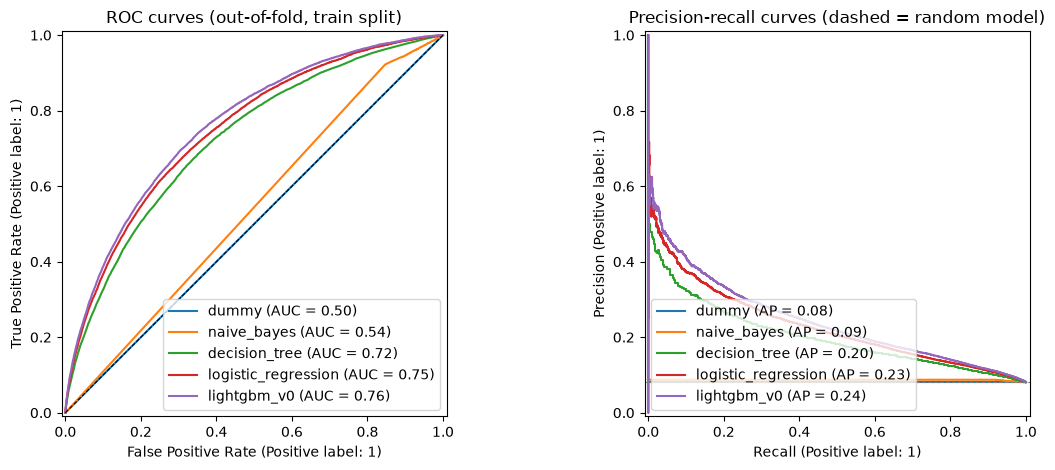

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for name, r in results.items():
    RocCurveDisplay.from_predictions(y, r.oof, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y, r.oof, name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set_title("ROC curves (out-of-fold, train split)")
axes[1].axhline(y.mean(), color="grey", ls="--", lw=0.8)
axes[1].set_title("Precision-recall curves (dashed = random model)")
fig.tight_layout()
fig.savefig(FIG / "fig11_baselines_roc_pr.png", dpi=150, bbox_inches="tight")
print("saved reports/figures/fig11_baselines_roc_pr.png")

## Is LightGBM really better than logistic regression?
Paired bootstrap: the same resamples for both models.

In [12]:
diff = paired_bootstrap(y, results["lightgbm_v0"].oof, results["logistic_regression"].oof,
                        n_boot=500)
facts["lgbm_minus_logreg_auc"] = round(diff["difference"], 4)
facts["lgbm_minus_logreg_ci"] = (round(diff["low"], 4), round(diff["high"], 4))
print(f"LightGBM minus logistic regression: {diff['difference']:+.4f} ROC-AUC, "
      f"95% CI [{diff['low']:+.4f}, {diff['high']:+.4f}], significant: {diff['significant']}")

LightGBM minus logistic regression: +0.0129 ROC-AUC, 95% CI [+0.0108, +0.0147], significant: True


## Regression experiment: can we fill in a missing `EXT_SOURCE_1`? (syllabus unit 4)

`EXT_SOURCE_1` is missing for more than half the applicants. Here **linear regression** predicts it
from the other columns. It's trained on folds 2–5 (rows where the value is known) and checked on
fold 1. The baseline is "always guess the median". Columns built *from* `EXT_SOURCE_1`
(mean, min, max, ...) are left out, because they would leak the answer.

Two versions are compared. **Plain least squares** gets huge, unstable coefficients because many
columns copy each other (EDA found 64 highly correlated pairs; this is called multicollinearity).
**Ridge regression** adds an L2 penalty (in Bayesian terms, a Gaussian prior on the weights), which
keeps the coefficients small and stable. `RidgeCV` picks the penalty strength by cross-validation.

In [13]:
target_col = "APP_EXT_SOURCE_1"
keep_ext = ("APP_EXT_SOURCE_2", "APP_EXT_SOURCE_3")
predictors = [c for c in groups["numeric"]
              if c != target_col and (not c.startswith("APP_EXT_") or c in keep_ext)]
known = X[target_col].notna().to_numpy()
fit_rows, check_rows = known & (folds != 1), known & (folds == 1)

X_fit, y_fit = X.loc[fit_rows, predictors], X.loc[fit_rows, target_col]
X_check = X.loc[check_rows, predictors]
truth = X.loc[check_rows, target_col].to_numpy(dtype=float)

ols = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LinearRegression())
ridge = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                      RidgeCV(alphas=np.logspace(-2, 4, 13)))
ols.fit(X_fit, y_fit)
ridge.fit(X_fit, y_fit)
guesses = {
    "median (baseline)": np.full_like(truth, y_fit.median()),
    "least squares": ols.predict(X_check),
    "ridge (L2)": ridge.predict(X_check),
}
imputation = pd.DataFrame({
    "RMSE": {k: np.sqrt(mean_squared_error(truth, g)) for k, g in guesses.items()},
    "R2": {k: r2_score(truth, g) for k, g in guesses.items()},
    "largest |coefficient|": {
        "median (baseline)": np.nan,
        "least squares": np.abs(ols[-1].coef_).max(),
        "ridge (L2)": np.abs(ridge[-1].coef_).max(),
    },
}).round(4)
facts["ext1_ridge_r2"] = float(imputation.loc["ridge (L2)", "R2"])
display(imputation)
print(f"ridge penalty chosen by CV: alpha = {ridge[-1].alpha_:g}")

coefs = pd.Series(ridge[-1].coef_, index=predictors).sort_values(key=abs, ascending=False)
print("Strongest predictors of EXT_SOURCE_1 (ridge, standardised coefficients):")
print(coefs.head(8).round(4).to_string())

,RMSE,R2,largest |coefficient|
median (baseline),0.2112,-0.0014,NaN
least squares,0.1628,0.4050,0.1215
ridge (L2),0.1628,0.4051,0.1215


ridge penalty chosen by CV: alpha = 10
Strongest predictors of EXT_SOURCE_1 (ridge, standardised coefficients):
APP_AGE_YEARS            0.1215
APP_FLOORSMAX_AVG        0.0298
APP_INCOME_PER_PERSON    0.0233
APP_CNT_CHILDREN        -0.0214
APP_AMT_INCOME_TOTAL    -0.0212
APP_CNT_FAM_MEMBERS      0.0196
APP_FLOORSMAX_MEDI      -0.0195
APP_EXT_SOURCE_2         0.0177


## Key facts
Copy these numbers into your Findings below.

In [14]:
for name, r in results.items():
    s = r.summary
    facts[f"auc_{name}"] = (round(s["roc_auc"], 4), round(s["roc_auc_low"], 4),
                            round(s["roc_auc_high"], 4))
for key, value in facts.items():
    print(f"{key:<32} {value}")

dummy_accuracy_%                 91.93
dummy_recall_%                   0.0
lgbm_minus_logreg_auc            0.0129
lgbm_minus_logreg_ci             (0.0108, 0.0147)
ext1_ridge_r2                    0.4051
auc_dummy                        (0.5, 0.4959, 0.504)
auc_naive_bayes                  (0.5374, 0.535, 0.5396)
auc_decision_tree                (0.7237, 0.7193, 0.7277)
auc_logistic_regression          (0.7482, 0.7445, 0.7519)
auc_lightgbm_v0                  (0.7612, 0.7578, 0.7646)


## Findings

- Every model was trained on the same 5 folds of the train split (184,503 applicants, application table only).
- **Dummy:** 91.93% accuracy but it catches 0% of defaulters and its ROC-AUC is 0.50, so accuracy is useless here.
- **Naive Bayes:** ROC-AUC 0.537 (95% CI 0.535 to 0.540), barely better than random. It assumes independent features, but many columns copy each other, so it counts the same evidence many times.
- **Decision tree (depth 6):** ROC-AUC 0.724 (0.719 to 0.728).
- **Logistic regression:** ROC-AUC 0.748 (0.745 to 0.752).
- **LightGBM v0:** ROC-AUC 0.761 (0.758 to 0.765). It beats logistic regression by +0.0129 (paired bootstrap 95% CI +0.0108 to +0.0147), so the gain is significant.
- LightGBM is stable across folds (fold ROC-AUC 0.7612 ± 0.0049).
- **Regression imputation:** ridge regression predicts EXT_SOURCE_1 with R² = 0.41 (median guess: about 0). Plain least squares gives the same fit and the same largest coefficient (0.12): with 64,121 training rows the correlated columns do not blow up, so the ridge penalty (alpha = 10, chosen by CV) changes almost nothing. The strongest predictor is age (0.12 per standard deviation; the next one, FLOORSMAX_AVG, is 0.03).